<a href="https://colab.research.google.com/github/NadimD9000-byte/RMG-Worker-MSD-Prediction/blob/main/rmg_MSD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pyreadstat xgboost shap statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 12.0 MB/s eta 0:00:00


In [2]:
from google.colab import files
upload = files.upload()


Saving pone.0200122.s003.sav to pone.0200122.s003.sav


In [3]:
import numpy as np
import pandas as pd
import pyreadstat
file_name = list(upload.keys())[0]
df,meta = pyreadstat.read_sav(file_name)
print("Dataset shape:",df.shape)
print("\ncolumns:")
print(df.columns.tolist())
display(df.head())

Dataset shape: (232, 177)

columns:
['QA_01', 'QC_01', 'QC_02', 'QC_03', 'QE_02', 'QE_03', 'QE_04', 'QE_05', 'QE_06', 'QF_02', 'QG_01', 'QG_02', 'QG_03', 'QG_04', 'QG_05', 'QG_06', 'QG_07', 'QG_07_Others', 'QG_08', 'QG_08_Others', 'QH_01', 'QH_06', 'QM_01', 'QM_01a', 'QM_01a1', 'QM_01b', 'QM_01c', 'QM_01d', 'QM_01e', 'QM_01f', 'QM_01g', 'QM_01h', 'QM_01i', 'QM_01j', 'QM_02', 'QM_02a', 'QM_02a1', 'QM_02b', 'QM_02c', 'QM_02d', 'QM_02e', 'QM_02f', 'QM_02g', 'QM_02h', 'QM_02i', 'QM_02j', 'QM_03', 'QM_03a', 'QM_03a1', 'QM_03b', 'QM_03c', 'QM_03d', 'QM_03e', 'QM_03f', 'QM_03g', 'QM_03h', 'QM_03i', 'QM_03j', 'QM_04', 'QM_04a', 'QM_04a1', 'QM_04b', 'QM_04c', 'QM_04d', 'QM_04e', 'QM_04f', 'QM_04g', 'QM_04h', 'QM_04i', 'QM_04j', 'QM_05', 'QM_05a', 'QM_05a1', 'QM_05b', 'QM_05c', 'QM_05d', 'QM_05e', 'QM_05f', 'QM_05g', 'QM_05h', 'QM_05i', 'QM_05j', 'QM_06', 'QM_06a', 'QM_06a1', 'QM_06b', 'QM_06c', 'QM_06d', 'QM_06e', 'QM_06f', 'QM_06g', 'QM_06h', 'QM_06i', 'QM_06j', 'QM_07', 'QM_07a', 'QM_07a1', '

,QA_01,QC_01,QC_02,QC_03,QE_02,QE_03,QE_04,QE_05,QE_06,QF_02,...,total_monthly_income,backstatic,backdynamic,tot_mon_inc,bmicat2,total_job_duration_cat_2,Quintile_National,Quintile_Urban,Total_working_hour,Total_working_cat
0,2.0,1.535,59.0,25.040053,32.0,2.0,1.0,0.0,1.0,2.0,...,17090.0,2.0,NaN,3.0,3.0,1,4.0,3.0,12.0,1.0
1,2.0,1.600,35.2,13.750000,21.0,2.0,1.0,4.0,1.0,2.0,...,17089.0,2.0,NaN,3.0,1.0,1,4.0,2.0,12.0,1.0
2,2.0,1.565,47.0,19.189744,27.0,2.0,1.0,4.0,1.0,10.0,...,15090.0,2.0,NaN,3.0,2.0,1,4.0,2.0,11.0,1.0
3,2.0,1.420,40.0,19.837334,26.0,2.0,1.0,0.0,2.0,2.0,...,18600.0,2.0,NaN,3.0,2.0,1,4.0,3.0,12.0,1.0
4,2.0,1.390,52.0,26.913721,29.0,2.0,1.0,0.0,1.0,12.0,...,15290.0,2.0,NaN,3.0,3.0,1,5.0,4.0,11.0,1.0


In [4]:
print(df['Overall_MSD_12m'].value_counts(dropna=False))
print("\npercentage:")
print(df['Overall_MSD_12m'].value_counts(normalize=True)*100)

Overall_MSD_12m
1.0    122
0.0    110
Name: count, dtype: int64

percentage:
Overall_MSD_12m
1.0    52.586207
0.0    47.413793
Name: proportion, dtype: float64


In [5]:
Target = 'Overall_MSD_12m'
demo_ses_cols =[
    'QC_01','QC_02','bmi',
    'QE_02','QE_03','QE_04','QE_05','QE_06',
    'QF_02',
    'QG_01','QG_02','QG_03','QG_04','QG_05','QG_06',
    'QH_01','QH_06',
    'total_monthly_income',
    'Quintile_National'

]
QEC_COLS=[
    'QO_01a',
    'QO_02',
    'QO_03',
    'QO_04',
    'QO_05',
    'QO_06',
    'QO_07'
]
all_cols = demo_ses_cols+QEC_COLS+[Target]
missing_cols =[ c for c in all_cols if c not in df.columns]
print("missing columns:",missing_cols)
data = df[all_cols].copy()
print("modeling data shape:",data.shape)

missing columns: []
modeling data shape: (232, 27)


In [6]:
data = data.dropna(subset=[Target])
print("rows after removing missing target:",len(data))

rows after removing missing target: 232


In [7]:
num_cols=[
    'QC_01',
    'QC_02',
    'bmi',
    'QE_02',
    'QH_01',
    'QH_06',
    'total_monthly_income',
    'QO_01a',
    'QO_02',
    'QO_03',
    'QO_04',
    'QO_05',
    'QO_06',
    'QO_07'
]
cat_cols=[
    'QE_03',
    'QE_04',
    'QE_05',
    'QE_06',
    'QF_02',
    'QG_01',
    'QG_02',
    'QG_03',
    'QG_04',
    'QG_05',
    'QG_06',
    'Quintile_National'
]

Overall_MSD_12m
1    122
0    110
Name: count, dtype: int64


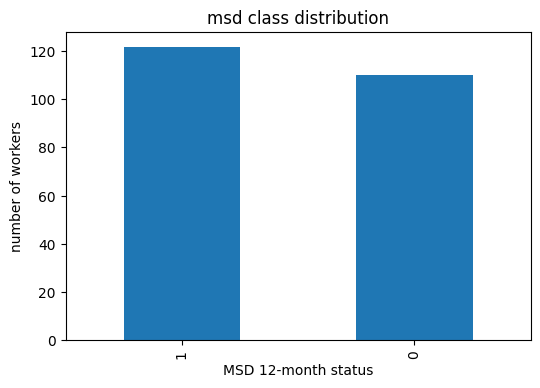

In [8]:
import matplotlib.pyplot as plt
y = data[Target].astype(int)
print(y.value_counts())
plt.figure(figsize=(6,4))
y.value_counts().plot(kind='bar')
plt.xlabel("MSD 12-month status")
plt.ylabel("number of workers")
plt.title("msd class distribution")
plt.show()

In [9]:
X_A =data[demo_ses_cols].copy()
X_B =data[demo_ses_cols+QEC_COLS].copy()
print("Model A shape:",X_A.shape)
print("Model B shape:",X_B.shape)
print("Target shape:",y.shape)

Model A shape: (232, 19)
Model B shape: (232, 26)
Target shape: (232,)


In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

In [11]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

def make_preprocessor(feature_columns):
  numeric_features = [c for c in feature_columns if c in num_cols]
  categorical_features = [c for c in feature_columns if c in cat_cols]
  numeric_Pipeline = Pipeline([
      ('imputer',SimpleImputer(strategy='median')),
      ('scaler',StandardScaler())
  ])
  categorical_Pipeline = Pipeline([
      ('imputer',SimpleImputer(strategy='most_frequent')),
      ('onehot',OneHotEncoder(handle_unknown='ignore',drop='first',sparse_output=False))
  ])
  preprocessor = ColumnTransformer([
      ('numeric',numeric_Pipeline,numeric_features),
      ('categorical',categorical_Pipeline,categorical_features)
  ])
  return preprocessor

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
def create_models(feature_columns):
  preprocessor = make_preprocessor(feature_columns)
  models = {
      'Logistic Regression':Pipeline([
          ('preprocessor',preprocessor),
          ('classifier',LogisticRegression(
              random_state=42,
              C=0.5,
              max_iter=5000
          ))
      ]),
      'Random Forest':Pipeline([
          ('preprocessor',preprocessor),
          ('classifier',RandomForestClassifier(
              n_estimators=300,
              random_state=42,
              max_depth=4,
              min_samples_leaf=8,
              n_jobs=-1
          ))
      ]),
      'xgboost':Pipeline([
          ('preprocessor',preprocessor),
          ('classifier',XGBClassifier(
              n_estimators=200,
              random_state=42,
              max_depth=3,
              learning_rate=0.05,
              subsample=0.8,
              colsample_bytree=0.8,
              eval_metric='logloss',
              n_jobs=-1))
      ])
  }
  return models

In [13]:
from sklearn.model_selection import RepeatedStratifiedKFold,cross_validate
cv=RepeatedStratifiedKFold(n_splits=5,
                           n_repeats=10,
                           random_state=42
                           )
scoring = {
    'auc':'roc_auc',
    'f1':'f1',
    'balanced_accuracy':'balanced_accuracy',

}
print("cv:5-fold 10 x repeats")
print("total validation runs per experiment:",5*10)

cv:5-fold 10 x repeats
total validation runs per experiment: 50


In [14]:
models_A = create_models(demo_ses_cols)

results_A = []
auc_scores_A = {}

for name, model in models_A.items():

    print(f"Running Model A - {name}...")

    scores = cross_validate(
        model,
        X_A,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    auc_scores_A[name] = scores['test_auc']

    results_A.append({
        'Feature Set': 'Model A',
        'Model': name,
        'AUC Mean': scores['test_auc'].mean(),
        'AUC SD': scores['test_auc'].std(),
        'F1 Mean': scores['test_f1'].mean(),
        'F1 SD': scores['test_f1'].std(),
        'Balanced Accuracy Mean': scores['test_balanced_accuracy'].mean(),
        'Balanced Accuracy SD': scores['test_balanced_accuracy'].std()
    })

results_A_df = pd.DataFrame(results_A)

display(results_A_df)

Running Model A - Logistic Regression...
Running Model A - Random Forest...
Running Model A - xgboost...


,Feature Set,Model,AUC Mean,AUC SD,F1 Mean,F1 SD,Balanced Accuracy Mean,Balanced Accuracy SD
0,Model A,Logistic Regression,0.413705,0.068723,0.491203,0.078367,0.433623,0.068308
1,Model A,Random Forest,0.503038,0.070352,0.600328,0.051956,0.514756,0.052653
2,Model A,xgboost,0.445592,0.071625,0.507516,0.073561,0.466111,0.066153


In [15]:
models_B = create_models(demo_ses_cols + QEC_COLS)

results_B = []
auc_scores_B = {}

for name, model in models_B.items():

    print(f"Running Model B - {name}...")

    scores = cross_validate(
        model,
        X_B,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )
    auc_scores_B[name] = scores['test_auc']

    results_B.append({
        'Feature Set': 'Model B',
        'Model': name,
        'AUC Mean': scores['test_auc'].mean(),
        'AUC SD': scores['test_auc'].std(),
        'F1 Mean': scores['test_f1'].mean(),
        'F1 SD': scores['test_f1'].std(),
        'Balanced Accuracy Mean': scores['test_balanced_accuracy'].mean(),
        'Balanced Accuracy SD': scores['test_balanced_accuracy'].std()
    })

results_B_df = pd.DataFrame(results_B)

display(results_B_df)

Running Model B - Logistic Regression...
Running Model B - Random Forest...
Running Model B - xgboost...


,Feature Set,Model,AUC Mean,AUC SD,F1 Mean,F1 SD,Balanced Accuracy Mean,Balanced Accuracy SD
0,Model B,Logistic Regression,0.574026,0.068395,0.565065,0.058141,0.541689,0.056707
1,Model B,Random Forest,0.624256,0.068851,0.654237,0.059909,0.595420,0.055491
2,Model B,xgboost,0.589968,0.055510,0.598294,0.066055,0.572177,0.064665


In [16]:
from scipy.stats import ttest_rel
import numpy as np

print("===== PAIRED MODEL A vs MODEL B AUC TEST =====")

for name in auc_scores_A.keys():

    A = auc_scores_A[name]
    B = auc_scores_B[name]

    # Paired t-test
    t_stat, p_value = ttest_rel(B, A)

    mean_A = np.mean(A)
    mean_B = np.mean(B)

    mean_difference = np.mean(B - A)

    print("\n" + name)
    print("-" * 40)
    print("Model A mean AUC:", round(mean_A, 4))
    print("Model B mean AUC:", round(mean_B, 4))
    print("Mean improvement:", round(mean_difference, 4))
    print("t-statistic:", round(t_stat, 4))
    print("p-value:", p_value)

===== PAIRED MODEL A vs MODEL B AUC TEST =====

Logistic Regression
----------------------------------------
Model A mean AUC: 0.4137
Model B mean AUC: 0.574
Mean improvement: 0.1603
t-statistic: 18.0897
p-value: 2.4812216919100912e-23

Random Forest
----------------------------------------
Model A mean AUC: 0.503
Model B mean AUC: 0.6243
Mean improvement: 0.1212
t-statistic: 13.2354
p-value: 8.436513244239966e-18

xgboost
----------------------------------------
Model A mean AUC: 0.4456
Model B mean AUC: 0.59
Mean improvement: 0.1444
t-statistic: 13.9916
p-value: 9.693146845593825e-19


In [17]:
all_results = pd.concat(
    [results_A_df, results_B_df],
    ignore_index=True
)

print("All six experiments:")
display(all_results)

All six experiments:


,Feature Set,Model,AUC Mean,AUC SD,F1 Mean,F1 SD,Balanced Accuracy Mean,Balanced Accuracy SD
0,Model A,Logistic Regression,0.413705,0.068723,0.491203,0.078367,0.433623,0.068308
1,Model A,Random Forest,0.503038,0.070352,0.600328,0.051956,0.514756,0.052653
2,Model A,xgboost,0.445592,0.071625,0.507516,0.073561,0.466111,0.066153
3,Model B,Logistic Regression,0.574026,0.068395,0.565065,0.058141,0.541689,0.056707
4,Model B,Random Forest,0.624256,0.068851,0.654237,0.059909,0.595420,0.055491
5,Model B,xgboost,0.589968,0.055510,0.598294,0.066055,0.572177,0.064665


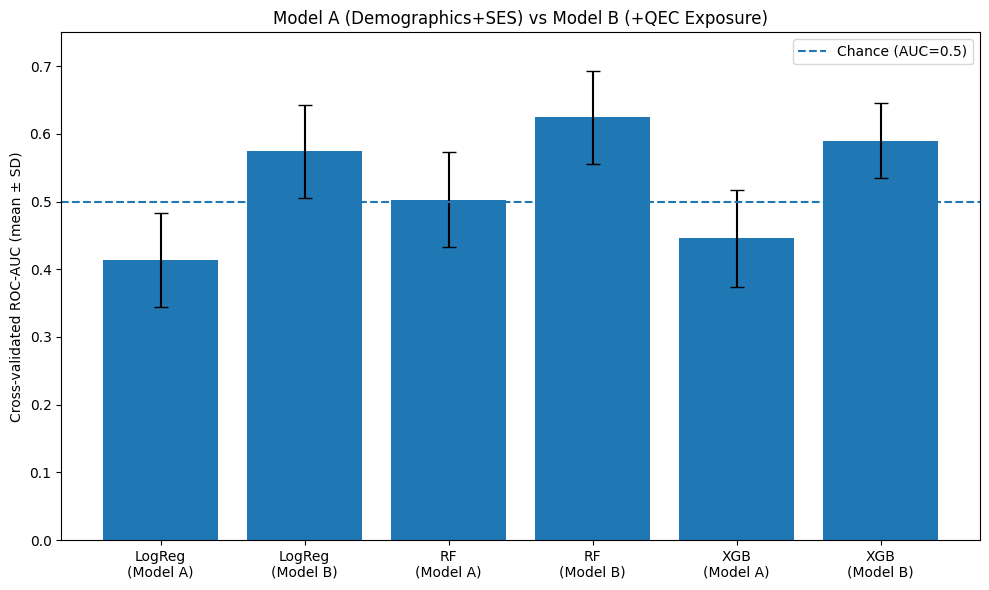

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Desired order of the six experiments
plot_order = [
    ('Model A', 'Logistic Regression'),
    ('Model B', 'Logistic Regression'),
    ('Model A', 'Random Forest'),
    ('Model B', 'Random Forest'),
    ('Model A', 'xgboost'),
    ('Model B', 'xgboost')
]

labels = []
means = []
stds = []

for feature_set, model_name in plot_order:

    row = all_results[
        (all_results['Feature Set'] == feature_set) &
        (all_results['Model'] == model_name)
    ].iloc[0]

    # Short names for the graph
    if model_name == 'Logistic Regression':
        short_name = 'LogReg'
    elif model_name == 'Random Forest':
        short_name = 'RF'
    else:
        short_name = 'XGB'

    labels.append(f'{short_name}\n({feature_set})')
    means.append(row['AUC Mean'])
    stds.append(row['AUC SD'])

# Create graph
x = np.arange(len(labels))

plt.figure(figsize=(10, 6))

plt.bar(
    x,
    means,
    yerr=stds,
    capsize=5
)

# Chance line
plt.axhline(
    y=0.5,
    linestyle='--',
    label='Chance (AUC=0.5)'
)

plt.xticks(x, labels)

plt.ylabel('Cross-validated ROC-AUC (mean ± SD)')
plt.title('Model A (Demographics+SES) vs Model B (+QEC Exposure)')

plt.ylim(0, 0.75)

plt.legend()

plt.tight_layout()
plt.show()

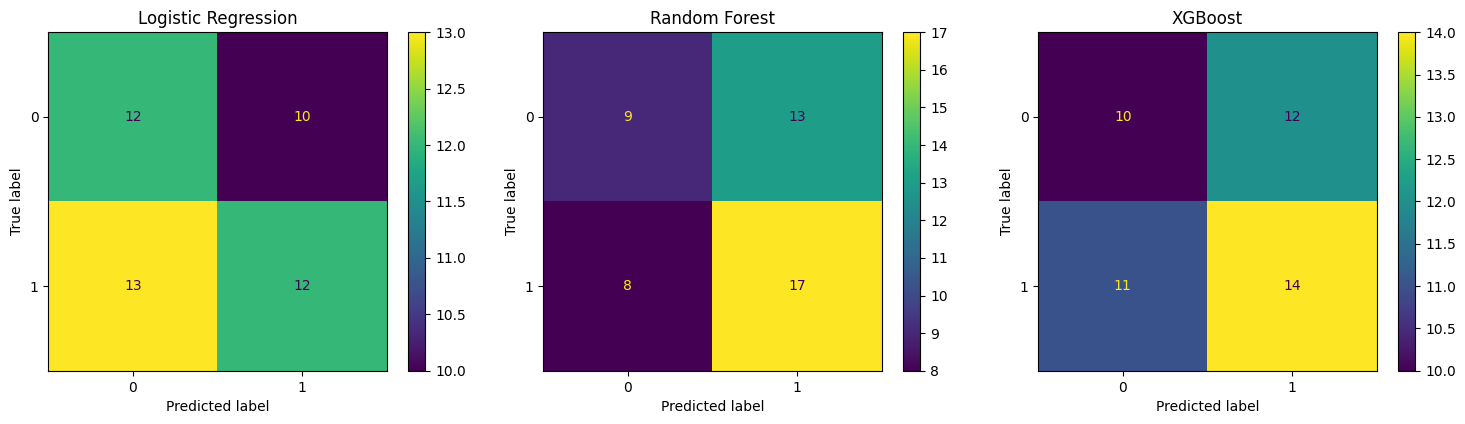

In [19]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Perform a train-test split to get a single test set for plotting
X_train, X_test, y_train, y_test = train_test_split(X_B, y, test_size=0.2, random_state=42, stratify=y)

# Re-initialize models for Model B and train them on the split data
models_B_for_plotting = create_models(demo_ses_cols + QEC_COLS)

y_pred_lr = None
y_pred_rf = None
y_pred_xgb = None

y_prob_lr = None # Added for ROC curve plotting in the next cell
y_prob_rf = None
y_prob_xgb = None

for name, model_pipeline in models_B_for_plotting.items():
    model_pipeline.fit(X_train, y_train) # Use y_train for training
    y_pred = model_pipeline.predict(X_test)
    y_prob = model_pipeline.predict_proba(X_test)[:, 1] # Probability of the positive class

    if name == 'Logistic Regression':
        y_pred_lr = y_pred
        y_prob_lr = y_prob
    elif name == 'Random Forest':
        y_pred_rf = y_pred
        y_prob_rf = y_prob
    elif name == 'xgboost':
        y_pred_xgb = y_pred
        y_prob_xgb = y_prob


fig,axes=plt.subplots(1,3,figsize=(15,4))
ConfusionMatrixDisplay.from_predictions(
    y_test,y_pred_lr,ax=axes[0]
)
axes[0].set_title('Logistic Regression')
ConfusionMatrixDisplay.from_predictions(
    y_test,y_pred_rf,ax=axes[1]
)
axes[1].set_title('Random Forest')
ConfusionMatrixDisplay.from_predictions(
    y_test,y_pred_xgb,ax=axes[2]
)
axes[2].set_title('XGBoost')
plt.tight_layout()
plt.show()

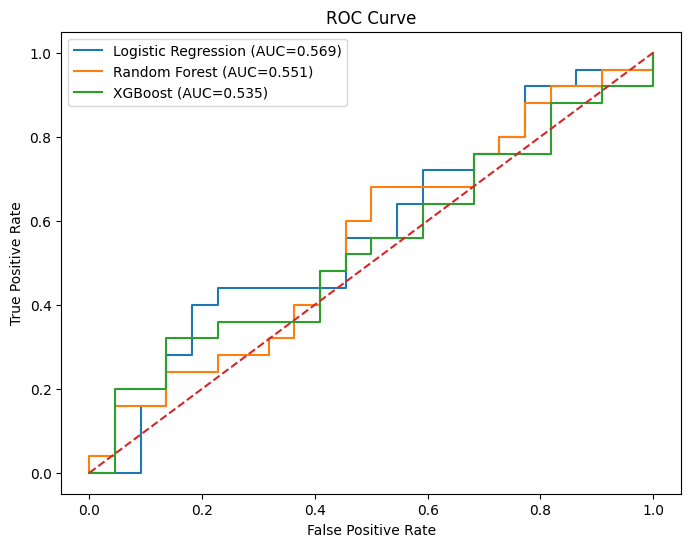

In [20]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
for name,prob in[
  ('Logistic Regression',y_prob_lr),
    ('Random Forest',y_prob_rf),
    ('XGBoost',y_prob_xgb)
]:
  fpr,tpr,_=roc_curve(y_test,prob)
  roc_auc=auc(fpr,tpr)
  plt.plot(fpr,tpr,label=f'{name} (AUC={roc_auc:.3f})')
plt.plot([0,1],[0,1],linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [21]:
rf_model = models_B_for_plotting['Random Forest']
importances = rf_model.named_steps['classifier'].feature_importances_
preprocessor = rf_model.named_steps['preprocessor']

transformed_feature_names = preprocessor.get_feature_names_out()

# Convert to list explicitly to ensure consistent behavior
transformed_feature_names_list = list(transformed_feature_names)
importances_list = list(importances) # Ensure it's a list for comparison

print(f"DEBUG: Length of transformed_feature_names: {len(transformed_feature_names_list)}")
print(f"DEBUG: Length of importances: {len(importances_list)}")

# Ensure the lengths match, providing generic names if there's a discrepancy
if len(transformed_feature_names_list) != len(importances_list):
    print(f"Warning: Mismatch in length detected. Generating generic feature names to match importance length.")
    transformed_feature_names_list = [f'feature_{i}' for i in range(len(importances_list))]

# If after the above check, lengths still don't match (should not happen with the generic name generation)
# or if it's a subtle pandas issue even with same lengths, raise an explicit error.
if len(transformed_feature_names_list) != len(importances_list):
    raise ValueError("Internal inconsistency: Feature names and importances still have different lengths after attempted correction.")

importance =pd.DataFrame({
    'feature':transformed_feature_names_list,
    'importance':importances_list
})
importance = importance.sort_values('importance',ascending=False)
display(importance.head(20))

DEBUG: Length of transformed_feature_names: 52
DEBUG: Length of importances: 52


,feature,importance
1,numeric__QC_02,0.118433
9,numeric__QO_03,0.112176
2,numeric__bmi,0.108763
7,numeric__QO_01a,0.101456
10,numeric__QO_04,0.087237
3,numeric__QE_02,0.082028
0,numeric__QC_01,0.059438
6,numeric__total_monthly_income,0.059333
8,numeric__QO_02,0.044446
12,numeric__QO_06,0.024138


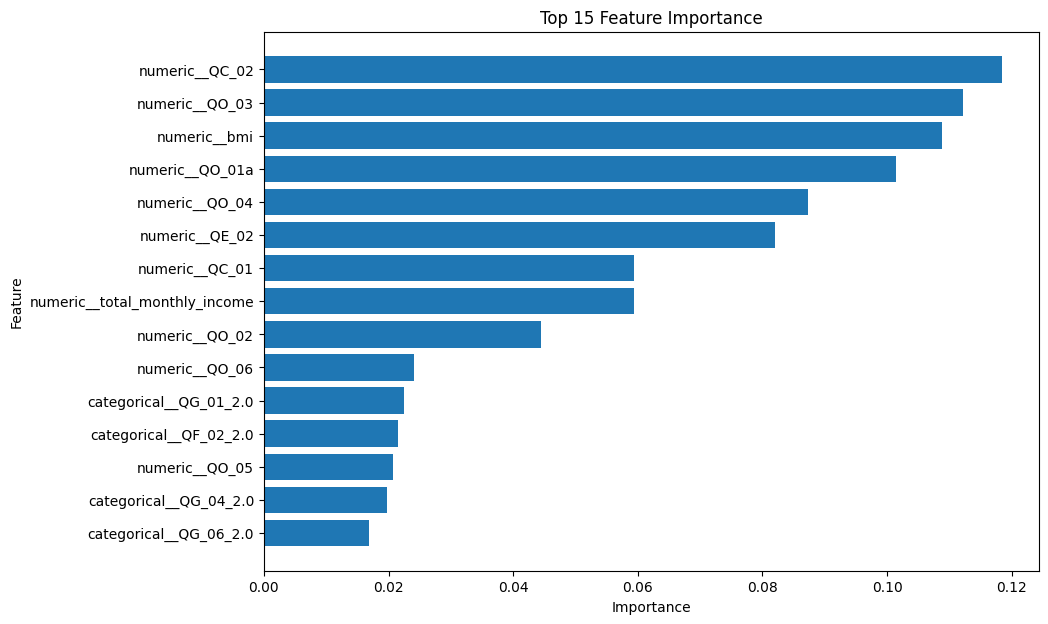

In [22]:
plt.figure(figsize=(10,7))
top_features = importance.head(15).sort_values('importance')
plt.barh(top_features['feature'],top_features['importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 15 Feature Importance')
plt.show()

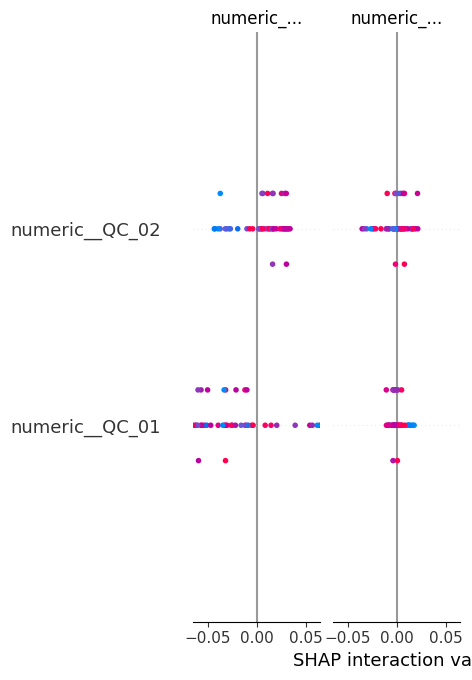

In [23]:
import shap
rf_classifier = rf_model.named_steps['classifier']

rf_preprocessor = rf_model.named_steps['preprocessor']
X_test_preprocessed = rf_preprocessor.transform(X_test)

explainer = shap.TreeExplainer(rf_classifier)
shap_values = explainer.shap_values(X_test_preprocessed)

if isinstance(shap_values, list):
  shap_values = shap_values[1]

shap.summary_plot(shap_values, X_test_preprocessed, feature_names=rf_preprocessor.get_feature_names_out())